# Identification

Pour estimer les para du sys. Faire pour P^ et D^ mettre en tbs les résutlats

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

import package_DBR
from package_DBR import myRound, FOPDT, FOPDT_cost, SOPDT, SOPDT_cost

# Load data

In [44]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_DV_2026-03-08-16h39.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

DV


# Plot cleaned data

(0.0, 1199.0)

<Figure size 2200x2200 with 0 Axes>

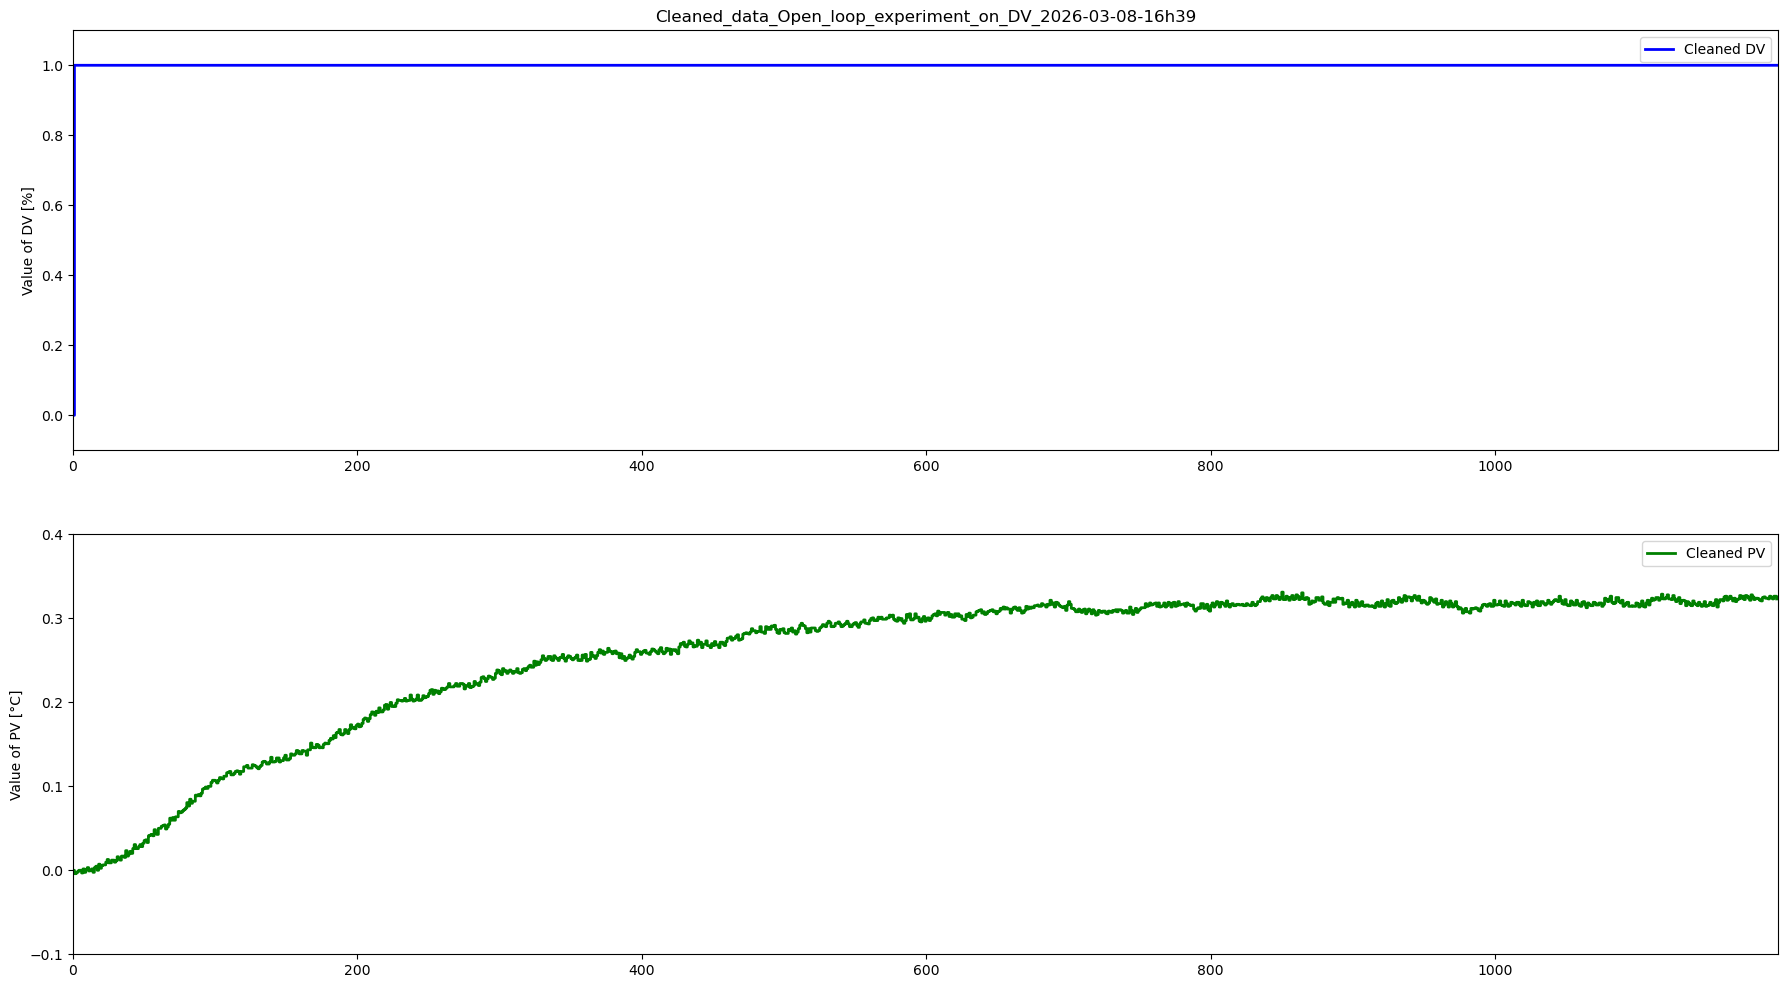

In [45]:
plt.figure(figsize = (22,22))

fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_figheight(12)
fig.set_figwidth(22)

if ExpVariable == 'MV':
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned MV',where='post')
    ax1.set_ylabel('Value of MV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,MVm)
    ax1.set_ylim(myRound(np.min(MVm),1)-0.1, myRound(np.max(MVm),1)+0.1)    
else:
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned DV',where='post')
    ax1.set_ylabel('Value of DV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,DVm)
    ax1.set_ylim(myRound(np.min(DVm),1)-0.1, myRound(np.max(DVm),1)+0.1)     

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='Cleaned PV',where='post')
ax2.set_ylabel('Value of PV [°C]')
ax2.legend(loc='best')
l2.set_data(tm,PVm)
ax2.set_ylim(myRound(np.min(PVm),0.1)-0.1, myRound(np.max(PVm),0.1)+0.1)

ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)

# Optimisation parameters

In [46]:
Ts = 1.0
model = 'FOPDT' #'FOPDT' ou 'SOPDT' faire les 2.

maxIter = 500

# if model == 'FOPDT':
#     bnds = ((None, None), (0, None), (0, None))
#     p0 = np.zeros(3)
#     p0[0] = 0.5 # K
#     p0[1] = 100.0 # T
#     p0[2] = 10.0 # theta

#     if ExpVariable == 'MV':
#         cost = FOPDT_cost(p0,MVm,PVm,Ts)
#     else:
#         cost = FOPDT_cost(p0,DVm,PVm,Ts)
# else:
#     bnds = ((None, None), (0, None), (0, None), (0, None))    
#     p0 = np.zeros(4)
#     p0[0] = 0.61 # K
#     p0[1] = 150.0 # T1
#     p0[2] = 6.0 # T2
#     p0[3] = 6.0 # theta

#     if ExpVariable == 'MV':
#         cost = SOPDT_cost(p0,MVm,PVm,Ts)
#     else:
#         cost = SOPDT_cost(p0,DVm,PVm,Ts)    

bnds1 = ((None, None), (0, None), (0, None))
p01 = np.zeros(3)
p01[0] = 0.5 # K
p01[1] = 100.0 # T
p01[2] = 10.0 # theta

if ExpVariable == 'MV':
    cost = FOPDT_cost(p01,MVm,PVm,Ts)
else:
    cost = FOPDT_cost(p01,DVm,PVm,Ts)

bnds2 = ((None, None), (0, None), (0, None), (0, None))    
p02 = np.zeros(4)
p02[0] = 0.61 # K
p02[1] = 150.0 # T1
p02[2] = 6.0 # T2
p02[3] = 6.0 # theta

if ExpVariable == 'MV':
    cost = SOPDT_cost(p02,MVm,PVm,Ts)
else:
    cost = SOPDT_cost(p02,DVm,PVm,Ts) 
    
print('Initial cost: ' + str(cost))

Initial cost: 91.12069681290266


# Optimisation

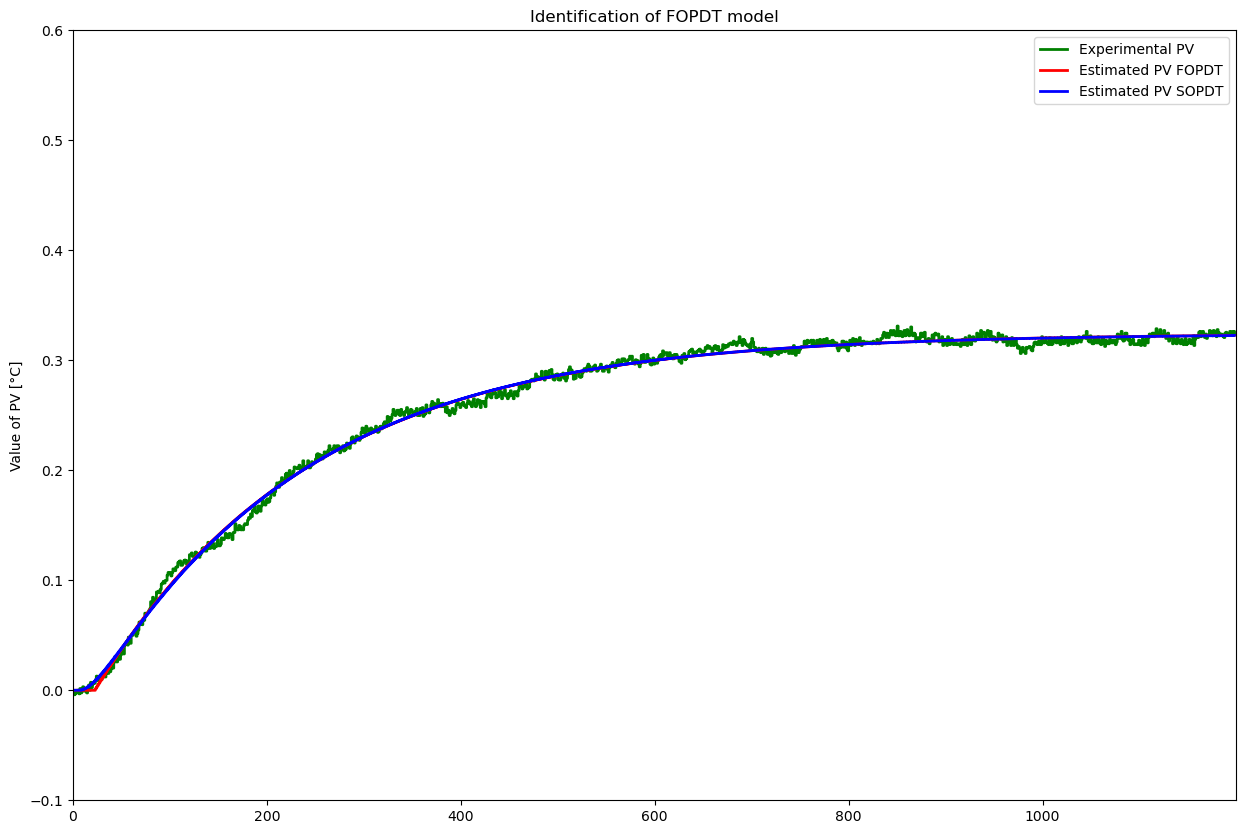

Final SSE Objective: 0.0316205335669502
K: 0.3241048096246215
T1: 221.16602071422838
T2: 16.741635805529068
theta: 5.453465939559135


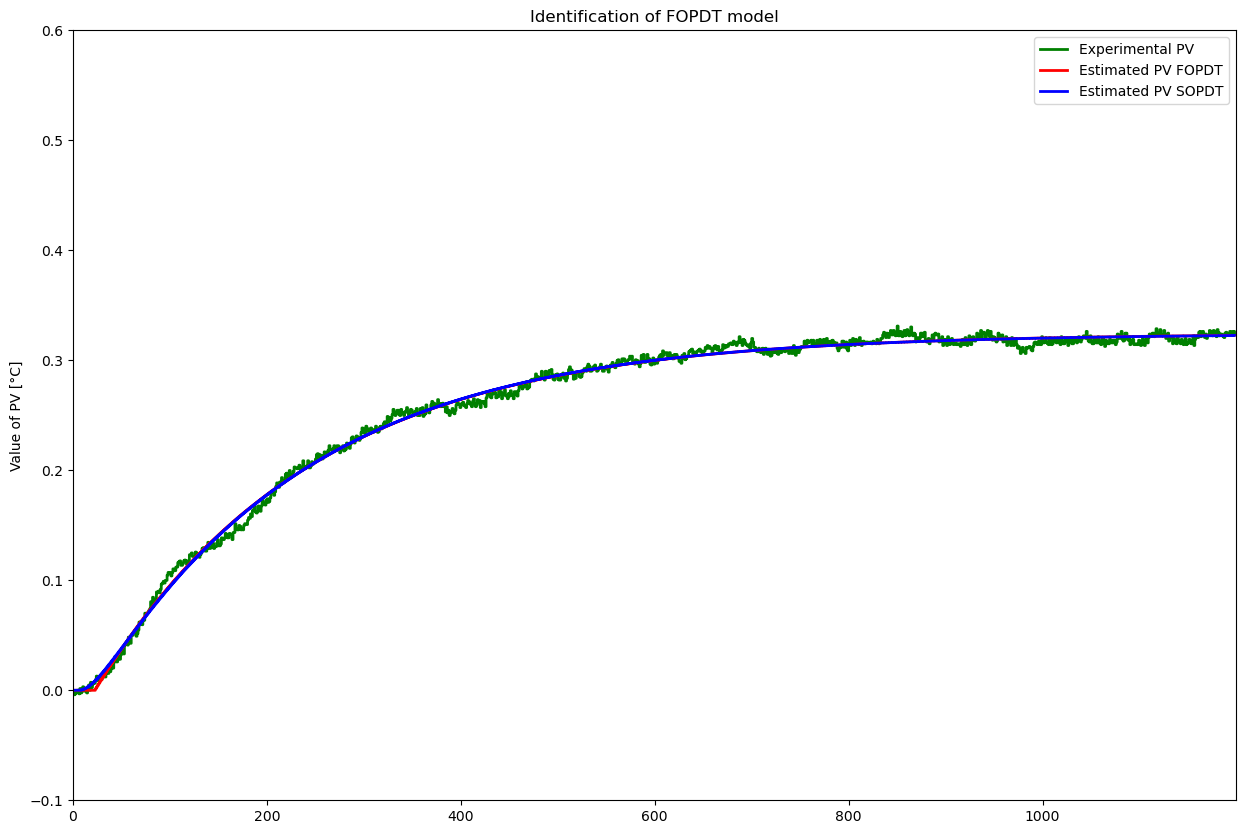

In [47]:
# optimize K, T, theta

fig, ax1 = plt.subplots()
fig.set_figheight(10)
fig.set_figwidth(15)
l1, = ax1.step([0,1],[0,1],'g-',linewidth=2,label='Experimental PV',where='post')
l2, = ax1.step([0,1],[0,1],'r-',linewidth=2,label='Estimated PV FOPDT',where='post')
l3, = ax1.step([0,1],[0,1],'b-',linewidth=2,label='Estimated PV SOPDT',where='post')
ax1.set_ylabel('Value of PV [°C]')
ax1.legend(loc='best')

# if model == 'FOPDT':
#     ax1.set_title('Identification of FOPDT model')
#     if ExpVariable == 'MV':
#         solution = minimize(FOPDT_cost,p0,args=(MVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds,options={'maxiter': maxIter})    
#         p = solution.x
#         print('Final SSE Objective: ' + str(FOPDT_cost(p,MVm,PVm,Ts)))
#     else:
#         solution = minimize(FOPDT_cost,p0,args=(DVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds,options={'maxiter': maxIter})    
#         p = solution.x
#         print('Final SSE Objective: ' + str(FOPDT_cost(p,DVm,PVm,Ts)))

#     K = p[0]
#     T = np.max([0,p[1]])
#     theta  = np.max([0,p[2]])

#     print('K: ' + str(K))
#     print('T: ' + str(T))
#     print('theta: ' + str(theta))
ax1.set_title('Identification of FOPDT model')
if ExpVariable == 'MV':
    solution = minimize(FOPDT_cost,p01,args=(MVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds1,options={'maxiter': maxIter})    
    p = solution.x
    print('Final SSE Objective: ' + str(FOPDT_cost(p,MVm,PVm,Ts)))
else:
    solution = minimize(FOPDT_cost,p01,args=(DVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds1,options={'maxiter': maxIter})    
    p = solution.x
    print('Final SSE Objective: ' + str(FOPDT_cost(p,DVm,PVm,Ts)))

K1 = p[0]
T = np.max([0,p[1]])
theta1  = np.max([0,p[2]])

print('K: ' + str(K1))
print('T: ' + str(T))
print('theta: ' + str(theta1))
# else:
#     ax1.set_title('Identification of SOPDT model')
#     if ExpVariable == 'MV':
#         solution = minimize(SOPDT_cost,p0,args=(MVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds,options={'maxiter': maxIter})
#         p = solution.x
#         print('Final SSE Objective: ' + str(SOPDT_cost(p,MVm,PVm,Ts)))
#     else:
#         solution = minimize(SOPDT_cost,p0,args=(DVm,PVm,Ts,(fig,ax1,l1,l2)), method='Powell',bounds=bnds,options={'maxiter': maxIter})    
#         p = solution.x
#         print('Final SSE Objective: ' + str(SOPDT_cost(p,DVm,PVm,Ts)))

#     K = p[0]
#     T1 = np.max([0,p[1]])
#     T2 = np.max([0,p[2]])
#     theta  = np.max([0,p[3]])

#     print('K: ' + str(K))
#     print('T1: ' + str(T1))
#     print('T2: ' + str(T2))
#     print('theta: ' + str(theta))  


if ExpVariable == 'MV':
    solution = minimize(SOPDT_cost,p02,args=(MVm,PVm,Ts,(fig,ax1,l1,l3)), method='Powell',bounds=bnds2,options={'maxiter': maxIter})
    q = solution.x
    print('Final SSE Objective: ' + str(SOPDT_cost(q,MVm,PVm,Ts)))
else:
    solution = minimize(SOPDT_cost,p02,args=(DVm,PVm,Ts,(fig,ax1,l1,l3)), method='Powell',bounds=bnds2,options={'maxiter': maxIter})    
    q = solution.x
    print('Final SSE Objective: ' + str(SOPDT_cost(q,DVm,PVm,Ts)))

K2 = q[0]
T1 = np.max([0,q[1]])
T2 = np.max([0,q[2]])
theta2  = np.max([0,q[3]])

print('K: ' + str(K2))
print('T1: ' + str(T1))
print('T2: ' + str(T2))
print('theta: ' + str(theta2))    

# Plot experimental and simulated data

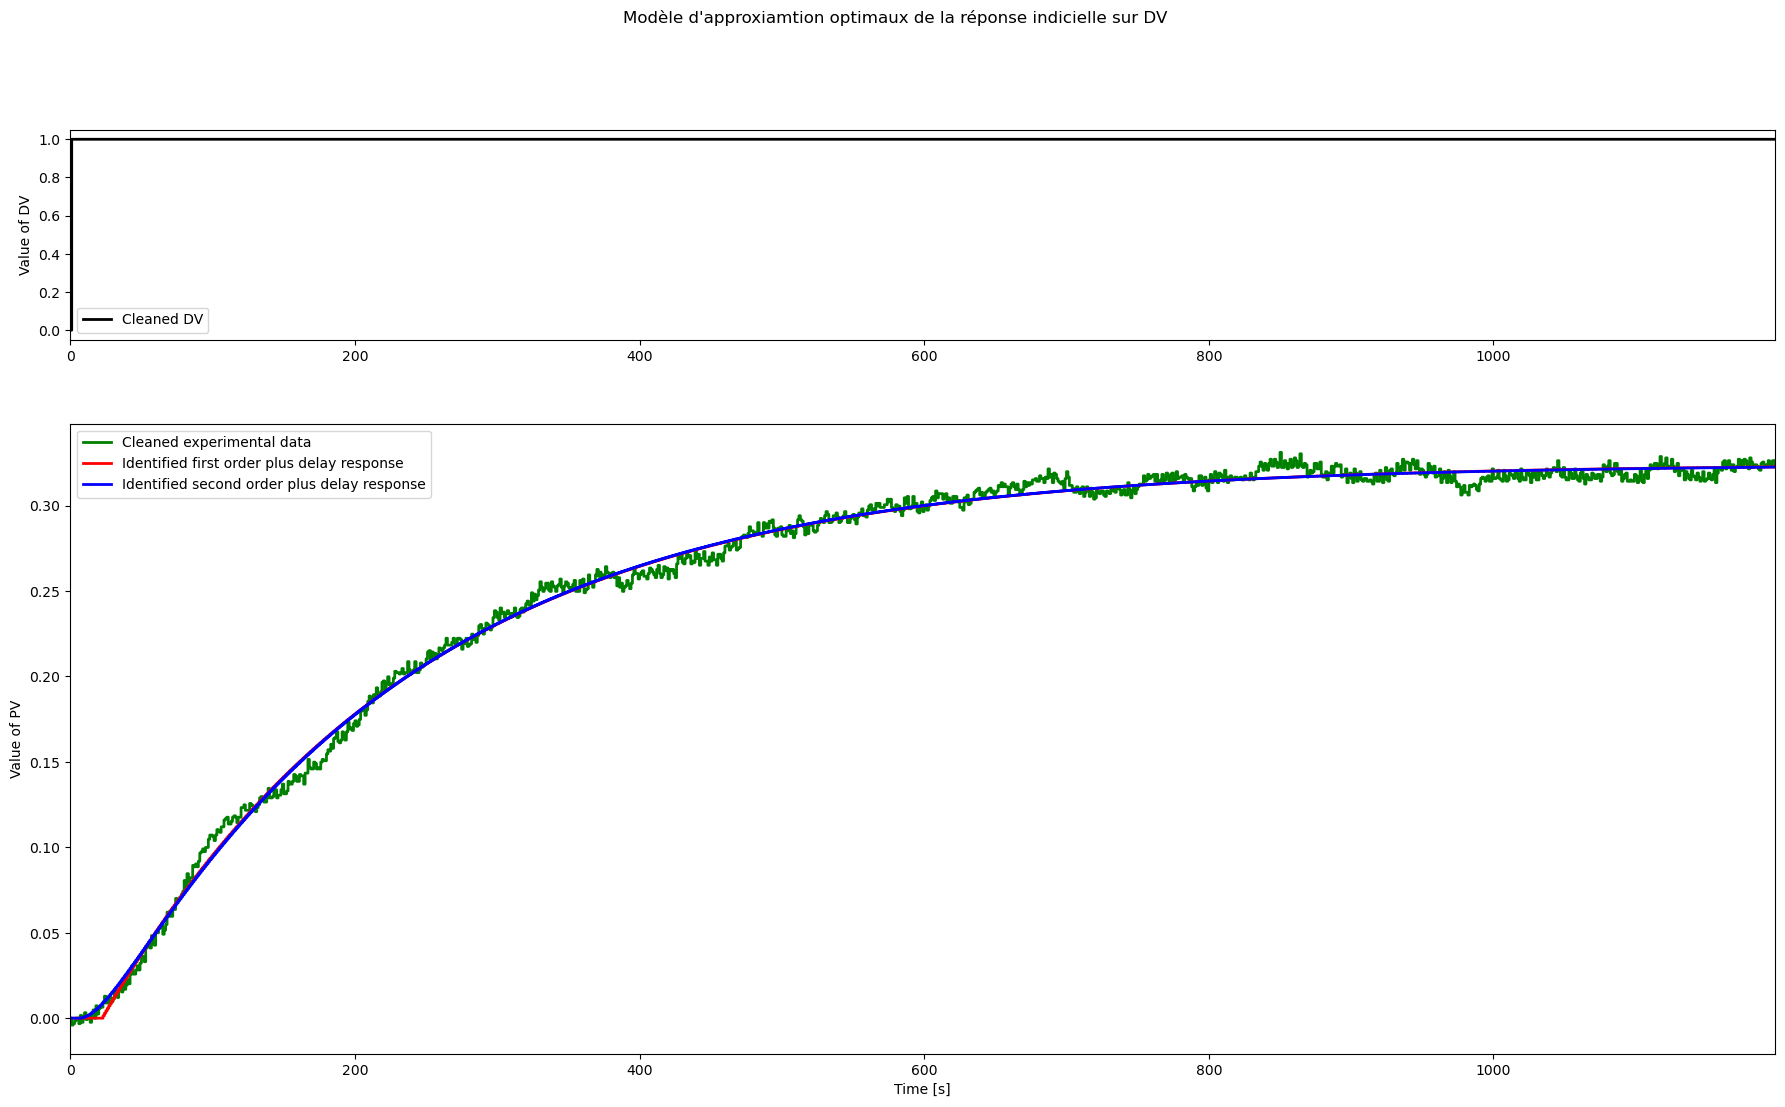

In [ ]:
# if model == 'FOPDT':
#     if ExpVariable == 'MV':
#         PVSim = FOPDT(MVm,K,T,theta,Ts)
#     else:
#         PVSim = FOPDT(DVm,K,T,theta,Ts)    
# else:
#     if ExpVariable == 'MV':
#         PVSim = SOPDT(MVm,K,T1,T2,theta,Ts)
#     else:
#         PVSim = SOPDT(DVm,K,T1,T2,theta,Ts)  
# 
 
if ExpVariable == 'MV':
    PVSim = FOPDT(MVm,K1,T,theta1,Ts)
    PVSimu = SOPDT(MVm,K2,T1,T2,theta2,Ts)
else:
    PVSim = FOPDT(DVm,K1,T,theta1,Ts) 
    PVSimu = SOPDT(DVm,K2,T1,T2,theta2,Ts)

        
# plt.figure(figsize = (22,12))

# plt.subplot(2,1,1)
# if ExpVariable == 'MV':
#     plt.step(tm,MVm,'d-',linewidth=2,label='Cleaned MV',where='post')
#     plt.ylabel('Value of MV')
# else:
#     plt.step(tm,DVm,'d-',linewidth=2,label='Cleaned DV',where='post')
#     plt.ylabel('Value of DV') 
    
# plt.legend(loc='best')
# plt.xlim([0, tm[-1]])

# plt.subplot(2,1,2)
# plt.step(tm,PVm,'g-',linewidth=2,label='Cleaned experimental data',where='post')
# plt.step(tm,PVSim,'r-',linewidth=2,label='Identified first order plus delay response',where='post')
# plt.step(tm,PVSimu,'b-',linewidth=2,label='Identified second order plus delay response',where='post')
# plt.ylabel('Value of PV')
# plt.xlabel('Time [s]')
# plt.legend(loc='best')
# plt.xlim([0, tm[-1]])


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 12), gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle("Modèle d'approxiamtion optimaux de la réponse indicielle sur DV")

if ExpVariable == 'MV':
    ax1.step(tm, MVm,'k-', linewidth=2, label='Cleaned MV', where='post')
    ax1.set_ylabel('Value of MV')
else:
    ax1.step(tm, DVm,'k-', linewidth=2, label='Cleaned DV', where='post')
    ax1.set_ylabel('Value of DV') 
    
ax1.legend(loc='best')
ax1.set_xlim([0, tm[-1]])

ax2.step(tm, PVm, 'g-', linewidth=2, label='Cleaned experimental data', where='post')
ax2.step(tm, PVSim, 'r-', linewidth=2, label='Identified first order plus delay response', where='post')
ax2.step(tm, PVSimu, 'b-', linewidth=2, label='Identified second order plus delay response', where='post')
ax2.set_ylabel('Value of PV')
ax2.set_xlabel('Time [s]')
ax2.legend(loc='best')
ax2.set_xlim([0, tm[-1]])

plt.show()

# if model == 'FOPDT':
#     plt.step(tm,PVSim,'r-',linewidth=2,label='Identified first order plus delay response',where='post')
#     plt.title('Experiment and identified first order plus delay response')
# else:
#     plt.step(tm,PVSim,'r-',linewidth=2,label='Identified second order plus delay response',where='post')
#     plt.title('Experiment and identified second order plus delay response')